In [ ]:
#Task 26/06/26
import pandas as pd

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Amazon_Sale_Report_Cleaned.csv to Amazon_Sale_Report_Cleaned.csv


In [ ]:
df = pd.read_csv("Amazon Sale Report.csv", low_memory=False)

In [ ]:
print(df.head())
print(df.info())
print(df.describe())

   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Category  ... currency  Amount    ship-city   ship-state  \
0            Set  ...      INR  647.

In [ ]:
print(df.isnull().sum())

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64


In [ ]:
df = df.drop_duplicates()

In [ ]:
print(df.duplicated().sum())

0


In [ ]:
df.drop(columns=["Unnamed: 22"], inplace=True)

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], format="%m-%d-%y")

In [ ]:
df["Courier Status"] = df["Courier Status"].fillna("Unknown")

df["promotion-ids"] = df["promotion-ids"].fillna("No Promotion")

df["fulfilled-by"] = df["fulfilled-by"].fillna("Not Available")

In [ ]:
df = df.dropna(subset=["Amount"])

In [ ]:
df["Amount"] = df["Amount"].fillna(df["Amount"].median())

In [ ]:
text_columns = [
    "Status",
    "Fulfilment",
    "Category",
    "ship-city",
    "ship-state"
]

for col in text_columns:
    df[col] = df[col].str.strip()

In [ ]:
df["ship-city"] = df["ship-city"].str.title()

df["ship-state"] = df["ship-state"].str.title()

In [ ]:
df["ship-postal-code"] = (
    df["ship-postal-code"]
      .fillna(0)
      .astype(int)
)

In [ ]:
df = df[df["Qty"] > 0]
df = df[df["Amount"] > 0]
print(df.dtypes)

index                          int64
Order ID                      object
Date                  datetime64[ns]
Status                        object
Fulfilment                    object
Sales Channel                 object
ship-service-level            object
Style                         object
SKU                           object
Category                      object
Size                          object
ASIN                          object
Courier Status                object
Qty                            int64
currency                      object
Amount                       float64
ship-city                     object
ship-state                    object
ship-postal-code               int64
ship-country                  object
promotion-ids                 object
B2B                             bool
fulfilled-by                  object
dtype: object


In [ ]:
df.to_csv("Amazon_Sale_Report_Cleaned.csv", index=False)

In [ ]:
from google.colab import files

files.download("Amazon_Sale_Report_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
#Task 29/06/26
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Amazon_Sale_Report_Cleaned.csv")

df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,Qty,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by
0,1,171-9198151-1101146,30-04-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,1,INR,406,Bengaluru,Karnataka,560085,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship
1,2,404-0687676-7273146,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,1,INR,329,Navi Mumbai,Maharashtra,410210,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,Not Available
2,4,407-1069790-7240320,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,1,INR,574,Chennai,Tamil Nadu,600073,IN,No Promotion,False,Not Available
3,5,404-1490984-4578765,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,...,1,INR,824,Ghaziabad,Uttar Pradesh,201102,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available
4,6,408-5748499-6859555,30-04-2022,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,...,1,INR,653,Chandigarh,Chandigarh,160036,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,Not Available


In [5]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(113701, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113701 entries, 0 to 113700
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   index               113701 non-null  int64 
 1   Order ID            113701 non-null  object
 2   Date                113701 non-null  object
 3   Status              113701 non-null  object
 4   Fulfilment          113701 non-null  object
 5   Sales Channel       113701 non-null  object
 6   ship-service-level  113701 non-null  object
 7   Style               113701 non-null  object
 8   SKU                 113701 non-null  object
 9   Category            113701 non-null  object
 10  Size                113701 non-null  object
 11  ASIN                113701 non-null  object
 12  Courier Status      113701 non-null  object
 13  Qty                 113701 non-null  int64 
 14  currency            113701 non-null  object
 15  Amount              113701 non-null  i

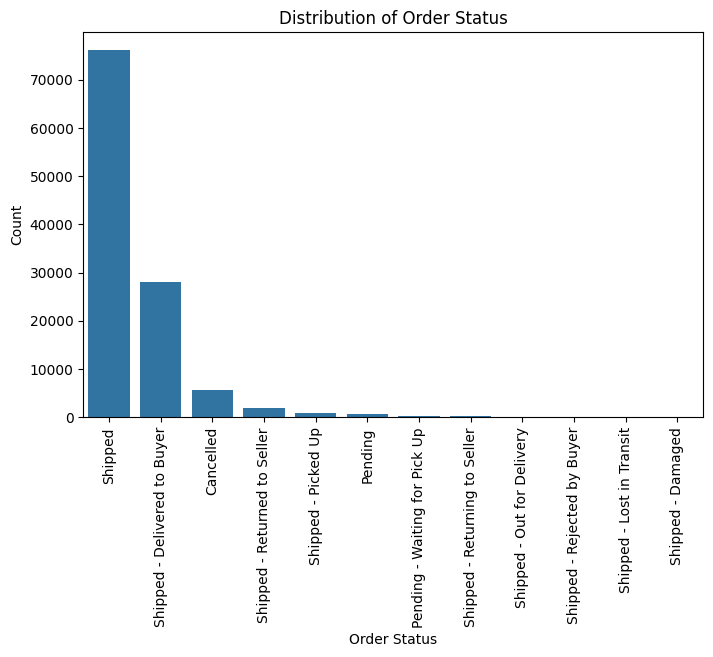

In [6]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Status', order=df['Status'].value_counts().index)

plt.xticks(rotation=90)
plt.title("Distribution of Order Status")
plt.xlabel("Order Status")
plt.ylabel("Count")

plt.show()

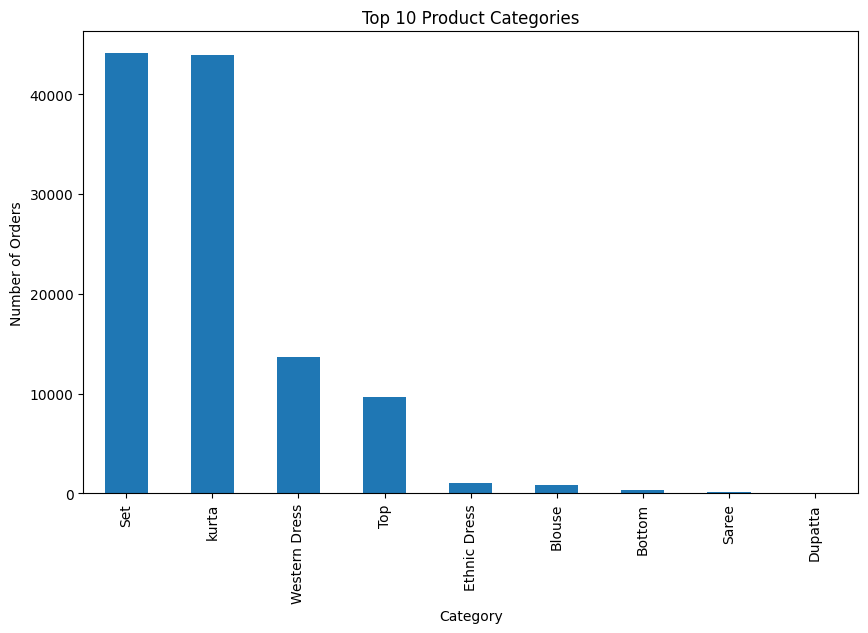

In [7]:
plt.figure(figsize=(10,6))

df['Category'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Orders")

plt.show()

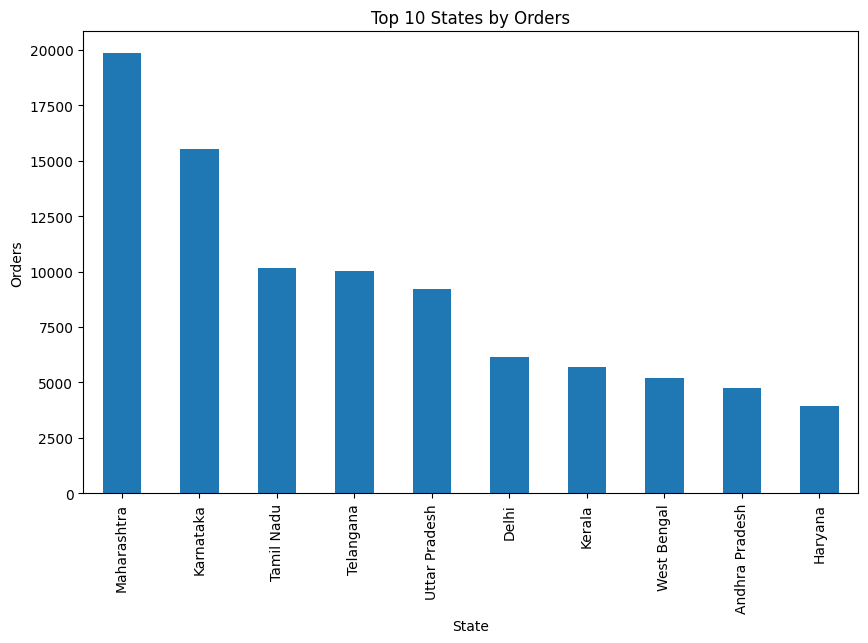

In [8]:
plt.figure(figsize=(10,6))

df['ship-state'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 States by Orders")
plt.xlabel("State")
plt.ylabel("Orders")

plt.show()

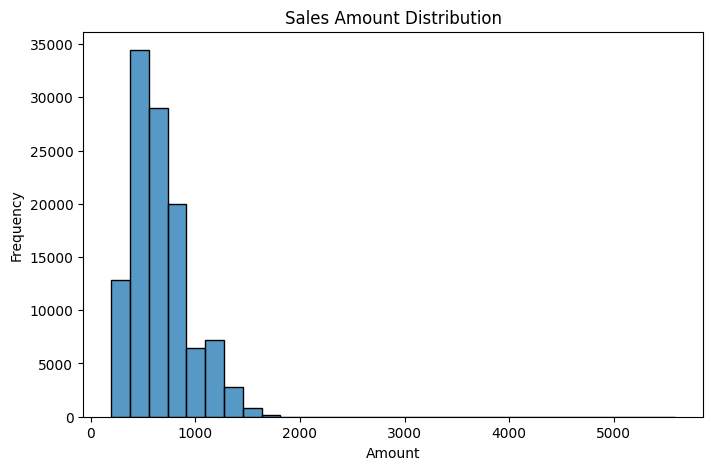

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(df['Amount'], bins=30)

plt.title("Sales Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

/tmp/ipykernel_929/2589208456.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


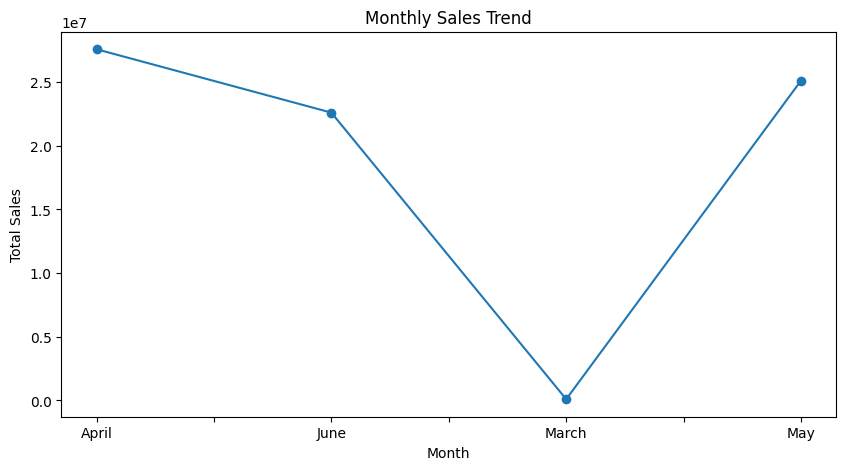

In [10]:
df['Date'] = pd.to_datetime(df['Date'])

df['Month'] = df['Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10,5))

monthly_sales.plot(marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

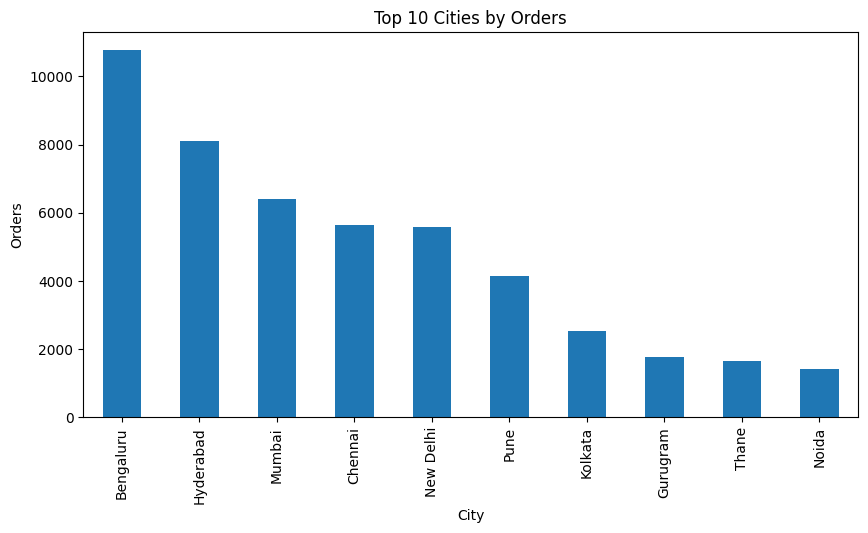

In [11]:
plt.figure(figsize=(10,5))

df['ship-city'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Cities by Orders")
plt.xlabel("City")
plt.ylabel("Orders")

plt.show()